## word2vec

### Imports

In [106]:
import numpy as np
from collections import Counter
import re
import matplotlib.pyplot as plt

In [107]:
class Dataset:
    """
    Pure NumPy Dataset class for word2vec training.
    Generates skip-gram pairs with negative sampling capability.
    """
    def __init__(self, filepath=None, text=None, window_size=5, min_count=5):
        """
        Initialize Dataset.
        
        Args:
            filepath: Path to text file (alternative to passing text directly)
            text: Raw text string (alternative to filepath)
            window_size: Context window size for skip-gram pairs
            min_count: Minimum word frequency to include in vocabulary
        """
        self.filepath = filepath
        self.text = text
        self.window_size = window_size
        self.min_count = min_count
        
        # Will be populated after preprocessing
        self.tokens = None
        self.word_index = None
        self.index_word = None
        self.word_counts = None
        self.vocab_size = None
        self.training_pairs = None
        self.neg_sampling_probs = None
    
    def load_text(self):
        """Load raw text from file or use provided text."""
        if self.filepath:
            with open(self.filepath, "r", encoding="utf-8") as f:
                self.text = f.read()
        elif self.text is None:
            raise ValueError("Either filepath or text must be provided")
        return self.text
    
    def tokenize(self):
        """
        Tokenize text: lowercase and extract alphabetic tokens.
        Pure NumPy/Python implementation (no Keras dependency).
        """
        if self.text is None:
            self.load_text()
        
        # Simple regex tokenization
        self.text = self.text.lower()
        self.tokens = re.findall(r"[a-z']+", self.text)
        return self.tokens
    
    def build_vocabulary(self):
        """
        Build vocabulary with frequency filtering.
        Creates word_index (word→id), index_word (id→word), and word_counts.
        """
        if self.tokens is None:
            self.tokenize()
        
        # Count word frequencies
        word_freq_counter = Counter(self.tokens)
        
        # Sort by frequency
        kept_words = [
            (word, freq) for word, freq in word_freq_counter.items() 
            if freq >= self.min_count
        ]
        kept_words.sort(key=lambda x: (-x[1], x[0]))  # freq desc, then alphabetically
        
        self.index_word = ["<IDx>"] + [word for word, _ in kept_words]
        self.word_index = {word: idx for idx, word in enumerate(self.index_word)}
        self.vocab_size = len(self.index_word)
        
        # Build word count array (accumulate all words)
        self.word_counts = np.zeros(self.vocab_size, dtype=np.int64)
        for word, freq in word_freq_counter.items():
            idx = self.word_index.get(word, 0)
            self.word_counts[idx] += freq
        
        return self.word_index, self.index_word
    
    def encode_tokens(self):
        """
        Convert tokens to integer indices.
        Returns numpy array of shape (seq_len,)
        """
        if self.word_index is None:
            self.build_vocabulary()
        
        return np.array(
            [self.word_index.get(token, 0) for token in self.tokens],
            dtype=np.int32
        )
    
    def subsample_frequent_words(self, threshold=1e-5):
        """
        Subsample frequent words to reduce dominance of 'the', 'of', 'and', etc.
        Each word w is KEPT with probability:
            P(w) = (sqrt(freq / t) + 1) * (t / freq)
        where freq = count(w)/total_tokens and t = threshold (~1e-5).
        This is the formula from the original word2vec paper (Mikolov et al. 2013).
        """
        if self.word_counts is None or self.word_index is None:
            self.build_vocabulary()
        
        total = float(self.word_counts.sum())
        
        # Build keep probability for each word index
        keep_probs = np.ones(self.vocab_size)
        for idx in range(self.vocab_size):
            freq = self.word_counts[idx] / total
            if freq > 0:
                keep_probs[idx] = min(1.0, (np.sqrt(freq / threshold) + 1) * (threshold / freq))
        
        # Filter tokens - keep only those that pass the subsampling check
        filtered = []
        for token in self.tokens:
            if token in self.word_index:
                idx = self.word_index[token]
                if np.random.random() < keep_probs[idx]:
                    filtered.append(token)
        
        self.tokens = filtered
    
    def generate_skipgram_pairs(self):
        """
        Generate skip-gram (center, context) pairs with dynamic window.
        Compatible with word2vec.train() format.
        
        Returns:
            numpy array of shape (num_pairs, 2) with dtype int32
            Each row: [center_word_idx, context_word_idx]
        """
        encoded = self.encode_tokens()
        
        centers = []
        contexts = []
        
        n = len(encoded)
        for i in range(n):
            # Dynamic window: randomly choose size in [1, window_size]
            dynamic_window = np.random.randint(1, self.window_size + 1)
            start = max(0, i - dynamic_window)
            end = min(n, i + dynamic_window + 1)
            
            center = int(encoded[i])
            for j in range(start, end):
                if j != i:
                    context = int(encoded[j])
                    centers.append(center)
                    contexts.append(context)
        
        self.training_pairs = np.array(
            list(zip(centers, contexts)),
            dtype=np.int32
        )
        return self.training_pairs
    
    def compute_negative_sampling_distribution(self, power=0.75):
        """
        Compute unigram^0.75 distribution for negative sampling.
        
        Args:
            power: Exponent for unigram distribution (default 0.75 from paper)
            
        Returns:
            numpy array of probabilities
        """
        if self.word_counts is None:
            self.build_vocabulary()
        
        probs = self.word_counts.astype(np.float64) ** power
        probs /= probs.sum()
        self.neg_sampling_probs = probs
        return probs
    
    def preprocess(self):
        """
        Run full preprocessing pipeline:
        1. Tokenize
        2. Build vocabulary
        3. Subsample frequent words (reduces noise from stopwords)
        4. Generate skip-gram pairs
        5. Compute negative sampling distribution
        
        Returns:
            dict with all necessary data for training
        """
        self.tokenize()
        self.build_vocabulary()
        self.subsample_frequent_words()
        self.generate_skipgram_pairs()
        self.compute_negative_sampling_distribution()
        
        return {
            'training_pairs': self.training_pairs,
            'word_index': self.word_index,
            'index_word': self.index_word,
            'vocab_size': self.vocab_size,
            'word_counts': self.word_counts,
            'neg_sampling_probs': self.neg_sampling_probs
        }

### word2vec class implementation

In [108]:
class word2vec():
    """Skip-gram word2vec with negative sampling, implemented in pure NumPy."""

    def __init__(self, num_negative=5, embedding_dim=100, learning_rate=0.025, epochs=5):
        """Initialize word2vec hyperparameters.

        Args:
            num_negative: number of negative samples drawn per positive pair.
            embedding_dim: dimensionality of the word embeddings.
            learning_rate: initial learning rate (decays linearly to ~0 during training).
            epochs: number of full passes over the training pairs.
        """
        self.num_negative = num_negative
        self.n = embedding_dim
        self.lr = learning_rate
        self.epochs = epochs


    def sigmoid(self, x):
        """Numerically stable sigmoid activation.

        Args:
            x: scalar or np.ndarray of any shape.

        Returns:
            y: output of the sigmoid function, same shape as x.
        """
        x = np.clip(x, -500, 500)
        return 1.0 / (1.0 + np.exp(-x))


    def sample_negatives(self, positive_idx, num_samples):
        """Draw negative word indices from the noise distribution.

        Args:
            positive_idx: index of the positive context word to exclude.
            num_samples: number of negative samples to return.

        Returns:
            negatives: list of integer word indices.
        """
        negatives = []
        while len(negatives) < num_samples:
            neg_idx = np.random.choice(self.v_count, p=self.neg_sampling_probs)
            if neg_idx != positive_idx:
                negatives.append(neg_idx)
        return negatives


    def forward_pass(self, center_idx, pos_context_idx, neg_context_indices):
        """Compute scores for one (center, positive, negatives) triplet.

        Args:
            center_idx: integer index of the center word.
            pos_context_idx: integer index of the true context word.
            neg_context_indices: list of integer indices for the negative samples.

        Returns:
            pos_score: sigmoid score for the positive pair — pushed toward 1.
            neg_scores: list of sigmoid scores for negative pairs — pushed toward 1.
            h: center word embedding vector, shape (n,).
        """
        h = self.w1[center_idx, :]

        pos_score = self.sigmoid(np.dot(h, self.w2[:, pos_context_idx]))

        neg_scores = []
        for neg_idx in neg_context_indices:
            neg_score = self.sigmoid(-np.dot(h, self.w2[:, neg_idx]))
            neg_scores.append(neg_score)

        return pos_score, neg_scores, h


    def backprop(self, center_idx, pos_context_idx, neg_context_indices,
                                   pos_score, neg_scores, h):
        """Update W1 and W2 for one training pair via SGD.

        Computes the gradient for the center embedding BEFORE updating W2,
        so that the update uses the original (pre-step) context vectors.

        Args:
            center_idx: integer index of the center word.
            pos_context_idx: integer index of the positive context word.
            neg_context_indices: list of integer indices for negative samples.
            pos_score: positive sigmoid score from the forward pass.
            neg_scores: list of negative sigmoid scores from the forward pass.
            h: center word embedding, shape (n,). Cached from the forward pass.
        """
        pos_grad = -(1.0 - pos_score)

        # Accumulate dL/dh FIRST (using original W2)
        dL_dh = pos_grad * self.w2[:, pos_context_idx].copy()

        for i, neg_idx in enumerate(neg_context_indices):
            neg_grad = -(1.0 - neg_scores[i])
            dL_dh += neg_grad * (-self.w2[:, neg_idx])

        # Now update W2 (context matrix)
        self.w2[:, pos_context_idx] -= self.lr * pos_grad * h

        for i, neg_idx in enumerate(neg_context_indices):
            neg_grad = -(1.0 - neg_scores[i])
            self.w2[:, neg_idx] -= self.lr * neg_grad * (-h)

        # Update W1 (embedding matrix) — only the center row
        self.w1[center_idx, :] -= self.lr * dL_dh


    def train(self, training_data):
        """Train the skip-gram model on pre-generated (center, context) pairs.

        Before calling, set these attributes from a Dataset object:
            vocab_size, word_index, index_word, prob_negative.

        Args:
            training_data: np.ndarray of shape (num_pairs, 2) with dtype int32.
                Each row is [center_word_idx, context_word_idx].
        """
        # Bridge Dataset attributes to internal names
        if hasattr(self, 'vocab_size') and self.vocab_size is not None:
            self.v_count = self.vocab_size
        if hasattr(self, 'prob_negative') and self.prob_negative is not None:
            self.neg_sampling_probs = self.prob_negative

        # Initialize weight matrices
        scale = 0.5 / self.n
        self.w1 = np.random.uniform(-scale, scale, (self.v_count, self.n))
        self.w2 = np.zeros((self.n, self.v_count))

        total_pairs = len(training_data)
        total_steps = total_pairs * self.epochs
        global_step = 0
        initial_lr = self.lr
        min_lr = initial_lr * 0.0001

        for epoch in range(self.epochs):
            self.loss = 0

            # Shuffle training pairs each epoch
            indices = np.random.permutation(total_pairs)

            for idx in indices:
                center_idx, context_idx = training_data[idx]

                # Linear learning rate decay
                self.lr = max(min_lr, initial_lr * (1.0 - global_step / total_steps))
                global_step += 1

                neg_context_indices = self.sample_negatives(context_idx, self.num_negative)

                pos_score, neg_scores, h = self.forward_pass(
                    center_idx, context_idx, neg_context_indices
                )

                self.backprop(
                    center_idx, context_idx, neg_context_indices,
                    pos_score, neg_scores, h
                )

                # Accumulate loss
                self.loss += -np.log(pos_score + 1e-10)
                self.loss += -sum([np.log(ns + 1e-10) for ns in neg_scores])


    def evaluate(self, pairs):
        """Compute average negative-sampling loss on held-out pairs (no weight updates).

        Args:
            pairs: np.ndarray of shape (num_pairs, 2), same format as training_data.

        Returns:
            avg_loss: mean loss per pair.
        """
        total_loss = 0.0
        for center_idx, context_idx in pairs:
            neg_indices = self.sample_negatives(context_idx, self.num_negative)
            pos_score, neg_scores, _ = self.forward_pass(
                center_idx, context_idx, neg_indices
            )
            total_loss += -np.log(pos_score + 1e-10)
            total_loss += -sum(np.log(ns + 1e-10) for ns in neg_scores)
        return total_loss / len(pairs)


    def word_vec(self, word):
        """Return the learned embedding vector for a word.

        Args:
            word: string token (must exist in the vocabulary).

        Returns:
            v_w: np.ndarray of shape (n,).
        """
        w_index = self.word_index[word]
        v_w = self.w1[w_index]
        return v_w


    def word_sim(self, word, top_n):
        """Print the top-n most similar words by cosine similarity.

        Args:
            word: query word string.
            top_n: number of most-similar words to display.
        """
        w1_index = self.word_index[word]
        v_w1 = self.w1[w1_index]

        word_sim = {}
        for i in range(self.v_count):
            v_w2 = self.w1[i]
            theta_num = np.dot(v_w1, v_w2)
            theta_den = np.linalg.norm(v_w1) * np.linalg.norm(v_w2)
            theta = theta_num / theta_den
            w = self.index_word[i]
            word_sim[w] = theta

        words_sorted = sorted(word_sim.items(), key=lambda x: x[1], reverse=True)

        for w, sim in words_sorted[:top_n]:
            print(w, sim)

### Optimization

In [109]:

small_words = book_text.split()[:5000]
small_text = " ".join(small_words)

small_dataset = Dataset(text=small_text, window_size=5, min_count=3)
small_data = small_dataset.preprocess()
print(f"CV dataset: vocab={small_data['vocab_size']}, pairs={len(small_data['training_pairs']):,}")

K_FOLDS = 3
NUM_RUNS = 2

training_pairs = small_data['training_pairs']
n_pairs = len(training_pairs)

fold_indices = np.random.permutation(n_pairs)
fold_size = n_pairs // K_FOLDS
folds = []
for k in range(K_FOLDS):
    val_idx = fold_indices[k * fold_size : (k + 1) * fold_size]
    train_idx = np.concatenate([fold_indices[:k * fold_size], fold_indices[(k + 1) * fold_size:]])
    folds.append((training_pairs[train_idx], training_pairs[val_idx]))

def create_and_train(lr, dim, neg, train_pairs):
    """Helper: create, wire, train, and return a word2vec model."""
    m = word2vec(num_negative=neg, embedding_dim=dim, learning_rate=lr, epochs=1)
    m.vocab_size = small_data['vocab_size']
    m.word_index = small_data['word_index']
    m.index_word = small_data['index_word']
    m.prob_negative = small_data['neg_sampling_probs']
    m.train(train_pairs)
    return m

CV dataset: vocab=285, pairs=1,416


We will use grid search to find the best hyperparameters, starting with the learning rate.

In [110]:
# ── 1. Learning Rate Search (dim=100, neg=5) ────────────────────────
learning_rates = [0.01, 0.025, 0.05, 0.1]

cv_means_lr, cv_stds_lr = [], []

for lr in learning_rates:
    run_losses = []
    for run in range(NUM_RUNS):
        fold_losses = []
        for train_pairs, val_pairs in folds:
            m = create_and_train(lr, 100, 5, train_pairs)
            fold_losses.append(m.evaluate(val_pairs))
        run_losses.append(np.mean(fold_losses))

    cv_means_lr.append(np.mean(run_losses))
    cv_stds_lr.append(np.std(run_losses))
    print(f"  lr={lr:.3f}:  val loss = {cv_means_lr[-1]:.4f} ± {cv_stds_lr[-1]:.4f}")

BEST_LR = learning_rates[int(np.argmin(cv_means_lr))]

  lr=0.010:  val loss = 4.1589 ± 0.0000
  lr=0.025:  val loss = 4.1589 ± 0.0000
  lr=0.050:  val loss = 4.1589 ± 0.0000
  lr=0.100:  val loss = 4.1588 ± 0.0000


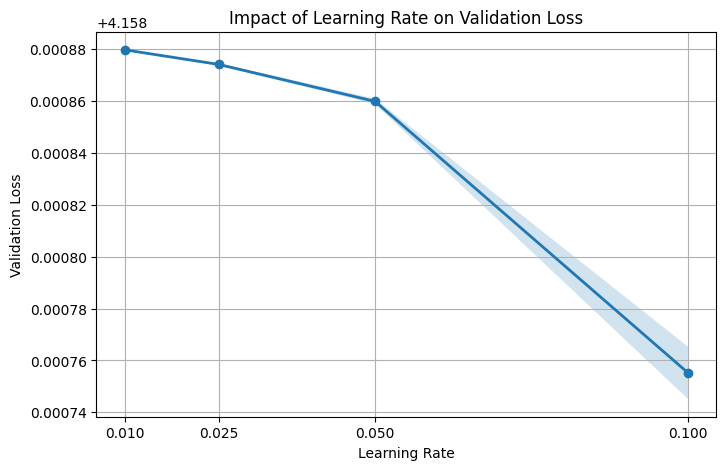


  ▸ Best learning rate: 0.1


In [111]:
means = np.array(cv_means_lr)
stds = np.array(cv_stds_lr)

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, means, marker='o', linewidth=2, zorder=3)
plt.fill_between(learning_rates, means - stds, means + stds, alpha=0.2, label='±1 std')
plt.xlabel("Learning Rate")
plt.xticks(learning_rates)
plt.ylabel("Validation Loss")
plt.title("Impact of Learning Rate on Validation Loss")
plt.grid(True)
plt.show()

print(f"\n  ▸ Best learning rate: {BEST_LR}")

Moving on to the dimensionality of the embeddings.

In [112]:
embedding_dims = [50, 100, 200]

cv_means_dim, cv_stds_dim = [], []

for dim in embedding_dims:
    run_losses = []
    for run in range(NUM_RUNS):
        fold_losses = []
        for train_pairs, val_pairs in folds:
            m = create_and_train(BEST_LR, dim, 5, train_pairs)
            fold_losses.append(m.evaluate(val_pairs))
        run_losses.append(np.mean(fold_losses))

    cv_means_dim.append(np.mean(run_losses))
    cv_stds_dim.append(np.std(run_losses))
    print(f"  dim={dim:3d}:  val loss = {cv_means_dim[-1]:.4f} ± {cv_stds_dim[-1]:.4f}")

BEST_DIM = embedding_dims[int(np.argmin(cv_means_dim))]

  dim= 50:  val loss = 4.1586 ± 0.0000
  dim=100:  val loss = 4.1588 ± 0.0000
  dim=200:  val loss = 4.1588 ± 0.0000


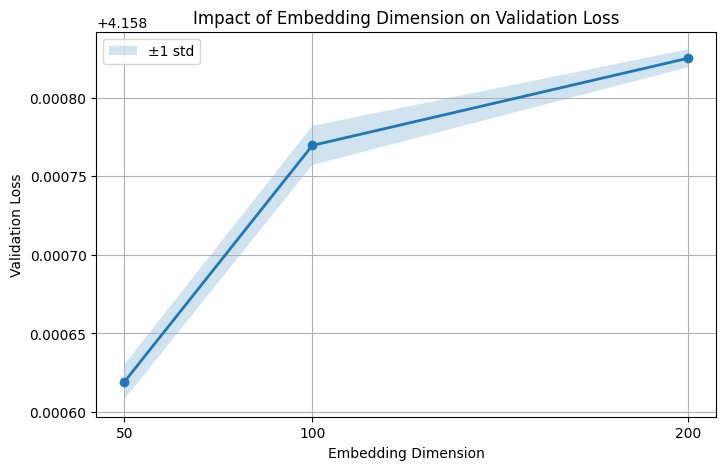


  ▸ Best embedding dim: 50


In [ ]:
Finally, the number of negative samples.
stds = np.array(cv_stds_dim)

plt.figure(figsize=(8, 5))
plt.plot(embedding_dims, means, marker='o', linewidth=2, zorder=3)
plt.fill_between(embedding_dims, means - stds, means + stds, alpha=0.2, label='±1 std')
plt.xlabel("Embedding Dimension")
plt.xticks(embedding_dims)
plt.ylabel("Validation Loss")
plt.title("Impact of Embedding Dimension on Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"\n  ▸ Best embedding dim: {BEST_DIM}")

Finally, the number of the negatives nums.

In [114]:
num_negatives = [3, 5, 8]

cv_means_neg, cv_stds_neg = [], []

for neg in num_negatives:
    run_losses = []
    for run in range(NUM_RUNS):
        fold_losses = []
        for train_pairs, val_pairs in folds:
            m = create_and_train(BEST_LR, BEST_DIM, neg, train_pairs)
            fold_losses.append(m.evaluate(val_pairs))
        run_losses.append(np.mean(fold_losses))

    cv_means_neg.append(np.mean(run_losses))
    cv_stds_neg.append(np.std(run_losses))
    print(f"  neg={neg:2d}:  val loss = {cv_means_neg[-1]:.4f} ± {cv_stds_neg[-1]:.4f}")

BEST_NEG = num_negatives[int(np.argmin(cv_means_neg))]

  neg= 3:  val loss = 2.7725 ± 0.0000
  neg= 5:  val loss = 4.1587 ± 0.0000
  neg= 8:  val loss = 6.2363 ± 0.0000


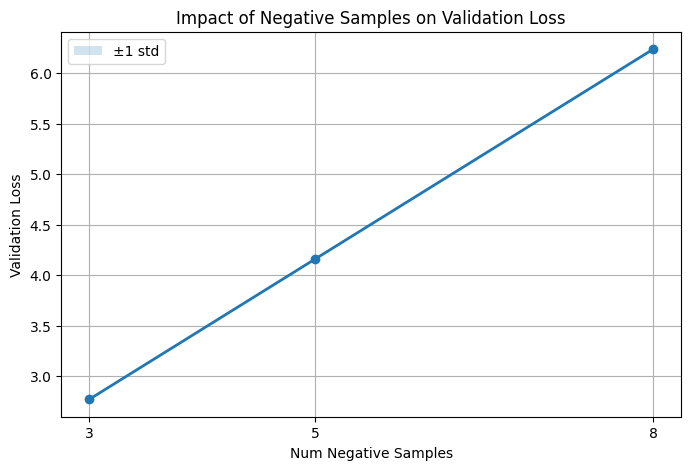


  ▸ Best num_negative: 3


In [115]:
means = np.array(cv_means_neg)
stds = np.array(cv_stds_neg)

plt.figure(figsize=(8, 5))
plt.plot(num_negatives, means, marker='o', linewidth=2, zorder=3)
plt.fill_between(num_negatives, means - stds, means + stds, alpha=0.2, label='±1 std')
plt.xlabel("Num Negative Samples")
plt.xticks(num_negatives)
plt.ylabel("Validation Loss")
plt.title("Impact of Negative Samples on Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"\n  ▸ Best num_negative: {BEST_NEG}")

In [ ]:
The best hyperparameters found from cross-validation will be used for training.

Best hyperparameters from CV:
  BEST_LR  = 0.1
  BEST_DIM = 50
  BEST_NEG = 3


We want to train the model and see how well it compares to real sample text.

In [121]:
sample_text = """
The quick brown fox jumps over the lazy dog. 
The dog was very lazy and slept all day.
The fox was quick and clever.
The brown fox was the quickest animal.
"""

# Initialize Dataset with sample text
dataset = Dataset(text=sample_text, window_size=2, min_count=1)

# Preprocess: tokenize, build vocabulary, generate skip-gram pairs
data_dict = dataset.preprocess()

# Initialize word2vec with configuration
model = word2vec(
    num_negative=BEST_NEG,
    embedding_dim=BEST_DIM,
    learning_rate=BEST_LR,
    epochs=5
)

# Set vocabulary and negative sampling distribution from dataset
model.vocab_size = data_dict['vocab_size']
model.word_index = data_dict['word_index']
model.index_word = data_dict['index_word']
model.prob_negative = data_dict['neg_sampling_probs']

# Train the model on the dataset
model.train(data_dict['training_pairs'])

test_word = 'fox'
if test_word in model.word_index:
    vec = model.word_vec(test_word)
    print(f"  Embedding for '{test_word}': {vec[:5]}... (shape: {vec.shape})")
    print(f"  Most similar to '{test_word}':")
    model.word_sim(test_word, top_n=5)
else:
    print(f"  '{test_word}' not in vocabulary")

  Embedding for 'fox': [-0.00815383 -0.00605735  0.00371519  0.00201993 -0.00437261]... (shape: (50,))
  Most similar to 'fox':
fox 0.9999999999999999
<IDx> 0.39350953771438824
lazy 0.282614363614222
jumps 0.26837772966633733
was 0.2644031476213534


### Training on The Count of Monte Cristo

Now let's train on real data — the full text of *The Count of Monte Cristo* (~61K lines, ~460K words).
We strip the Project Gutenberg header/footer using the markers defined earlier.

In [118]:
start_point = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_point = "*** END OF THE PROJECT GUTENBERG EBOOK"

In [119]:
# Load and strip Gutenberg boilerplate
filepath = "../data/Count_of_Monte_Cristo.txt"

with open(filepath, "r", encoding="utf-8") as f:
    raw_text = f.read()

# Strip header and footer using the markers defined earlier
start_idx = raw_text.find(start_point)
if start_idx != -1:
    start_idx = raw_text.index("\n", start_idx) + 1 
end_idx = raw_text.find(end_point)
if end_idx == -1:
    end_idx = len(raw_text)

book_text = raw_text[start_idx:end_idx]
print(f"Loaded text: {len(book_text):,} characters, ~{len(book_text.split()):,} words")

# Preprocess with realistic settings
monte_dataset = Dataset(text=book_text, window_size=5, min_count=5)
monte_data = monte_dataset.preprocess()

print(f"Vocabulary size: {monte_data['vocab_size']:,}")
print(f"Training pairs: {monte_data['training_pairs'].shape[0]:,}")

Loaded text: 2,627,265 characters, ~460,971 words
Vocabulary size: 5,717
Training pairs: 520,100


In [120]:
# Initialize word2vec for Monte Cristo
monte_model = word2vec(
    num_negative=BEST_NEG,
    embedding_dim=BEST_DIM,
    learning_rate=BEST_LR,
    epochs=3
)

# Wire up vocabulary and negative sampling distribution from dataset
monte_model.vocab_size = monte_data['vocab_size']
monte_model.word_index = monte_data['word_index']
monte_model.index_word = monte_data['index_word']
monte_model.prob_negative = monte_data['neg_sampling_probs']

# Train
monte_model.train(monte_data['training_pairs'])

KeyboardInterrupt: 

In [122]:
# Test embeddings on Monte Cristo
print("=== Word Similarity ===\n")

words = ['king', 'prison', 'treasure', 'love', 'death', 'paris', 'count']

for word in words:
    if word in monte_model.word_index:
        print(f"Top 5 most similar to '{word}':")
        monte_model.word_sim(word, top_n=5)
        print()
    else:
        print(f"'{word}' not in vocabulary\n")

=== Word Similarity ===

Top 5 most similar to 'king':
king 1.0
sometimes 0.9982350378374735
destined 0.9982254948911072
thrusting 0.9982085438526942
telegraphic 0.9982015958737575

Top 5 most similar to 'prison':
prison 0.9999999999999998
propriety 0.9988113057446099
triumphant 0.9988081855587195
pain 0.9988077854934525
constant 0.9987933294165454

Top 5 most similar to 'treasure':
treasure 1.0000000000000002
extremely 0.9988951869181087
many 0.9988905501694236
town 0.9988901697507754
suffering 0.9988618905966287

Top 5 most similar to 'love':
love 1.0
solemnly 0.9986624421393009
borgia 0.998558242776361
te 0.9984476890413562
newspaper 0.9984255774094389

Top 5 most similar to 'death':
death 0.9999999999999998
respectfully 0.9979112309953514
parbleu 0.9977603772222235
highest 0.997748906219589
gratify 0.997738833300625

Top 5 most similar to 'paris':
paris 1.0
chisel 0.9985530210096742
operation 0.9985526488388422
doctors 0.9985500737627767
condition 0.9985453900916311

Top 5 most sim

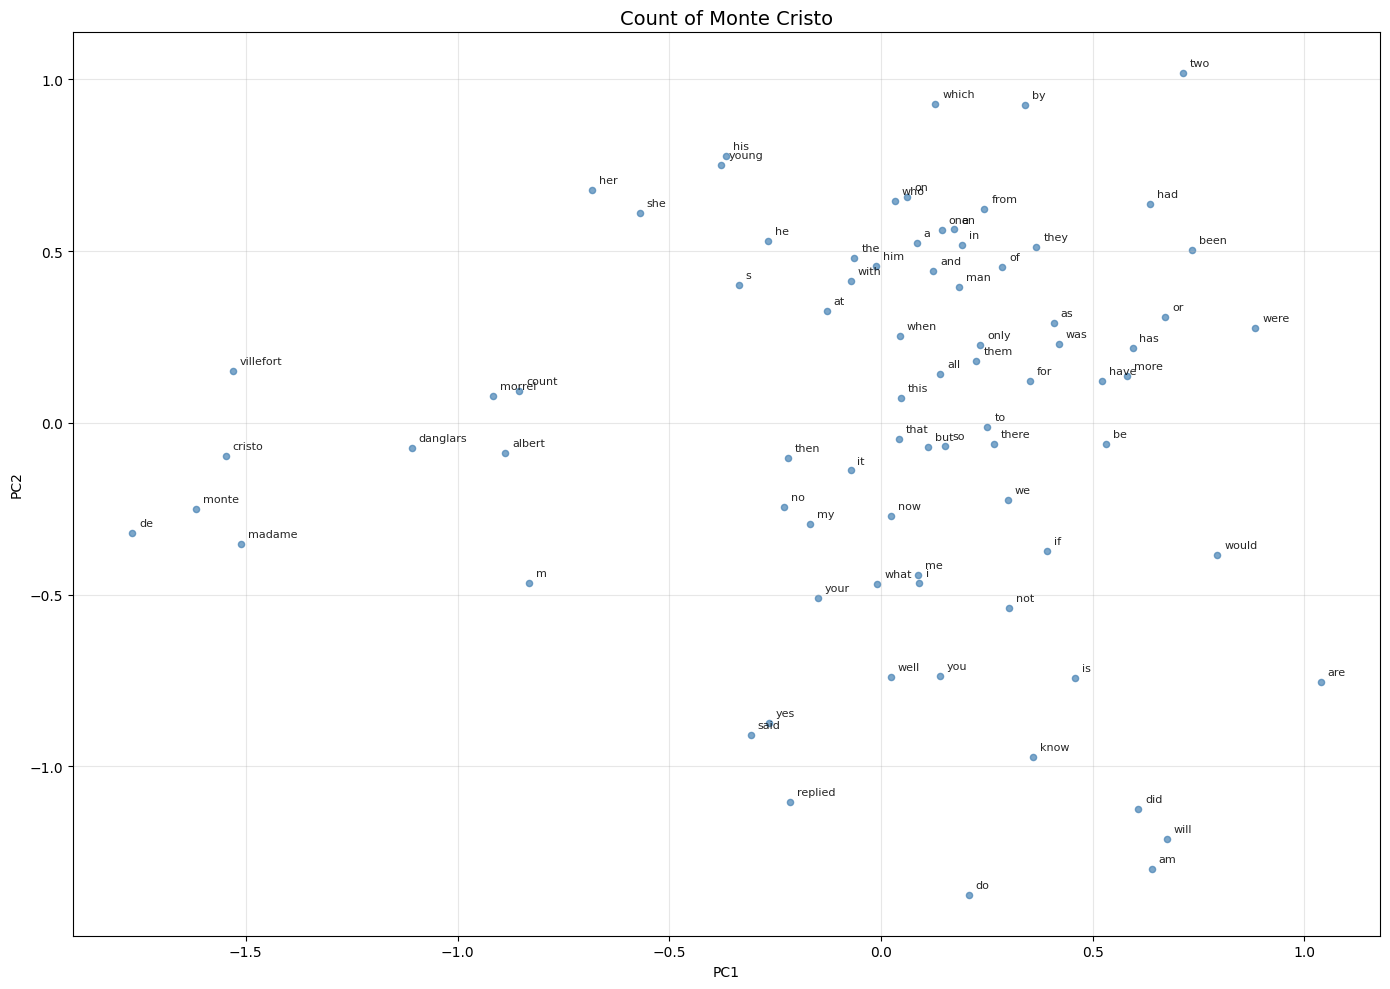

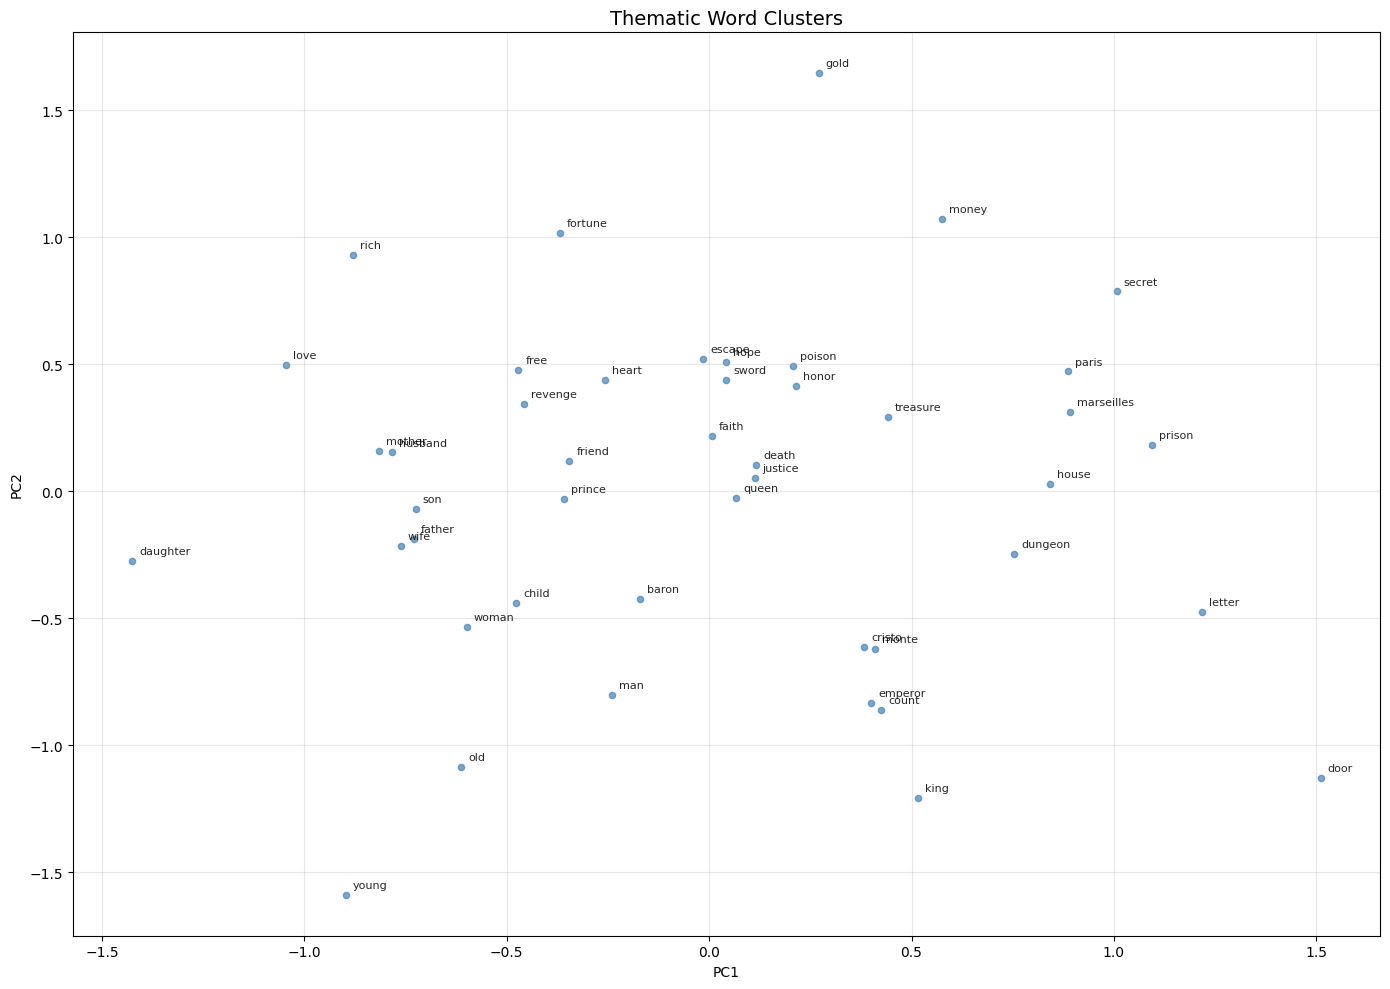

In [ ]:
plot_embeddings(monte_model, top_n=80, title="Count of Monte Cristo")

thematic_words = [
    'count', 'monte', 'cristo', 'paris', 'marseilles',
    'king', 'queen', 'emperor', 'prince', 'baron',
    'prison', 'dungeon', 'escape', 'free', 'death',
    'treasure', 'gold', 'money', 'rich', 'fortune',
    'love', 'heart', 'wife', 'husband', 'friend',
    'revenge', 'justice', 'honor', 'hope', 'faith',
    'father', 'mother', 'son', 'daughter', 'child',
    'sword', 'poison', 'letter', 'secret', 'door',
    'man', 'woman', 'young', 'old', 'house'
]
plot_embeddings(monte_model, words=thematic_words, title="Thematic Word Clusters")